# 05 · What happens during a tick?

## Learning objectives

- Follow requests downward and results upward.
- Distinguish state between ticks from work within a tick.
- Relate tick frequency to responsiveness.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

A tick is a traversal, not a unit of physical time. A parent calls selected children and
uses their return values. Between ticks the world can change. **Reactivity** comes from
repeatedly revisiting decisions. A tick period of 100 ms means new conditions are normally
noticed within about one period, plus computation and communication delay; it is not a
hard real-time guarantee.

In [2]:
from behavior_trees_tutorial.trees.core import Action, Sequence, Selector, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

In [3]:
events = []
environment = {"safe": True, "progress": 0}

def guard():
    events.append("  -> Safe?")
    result = Status.SUCCESS if environment["safe"] else Status.FAILURE
    events.append(f"  <- {result.name}")
    return result

def move():
    events.append("  -> Move")
    environment["progress"] += 1
    result = Status.SUCCESS if environment["progress"] >= 3 else Status.RUNNING
    events.append(f"  <- {result.name}")
    return result

root = Sequence("Safe movement", [Action("Safe?", guard), Action("Move", move)])

## Step-by-step implementation
The environment changes between ticks 2 and 3. Watch which child is no longer visited.

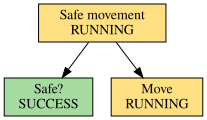

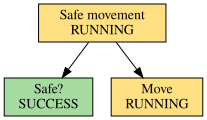

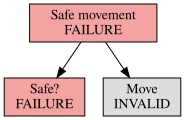

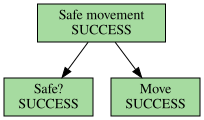

-> Root
  -> Safe?
  <- SUCCESS
  -> Move
  <- RUNNING
<- Root: RUNNING
-> Root
  -> Safe?
  <- SUCCESS
  -> Move
  <- RUNNING
<- Root: RUNNING
-> Root
  -> Safe?
  <- FAILURE
<- Root: FAILURE
-> Root
  -> Safe?
  <- SUCCESS
  -> Move
  <- SUCCESS
<- Root: SUCCESS


In [4]:
for safe in [True, True, False, True]:
    environment["safe"] = safe
    events.append("-> Root")
    events.append(f"<- Root: {root.tick().name}")
    display(diagram(root))
print("\n".join(events))
assert environment["progress"] == 3

## Interactive demonstration
Tick and Reset let you control logical time. Reset creates fresh state. This teaching
counter does not roll back movement when interrupted; resetting a status cannot undo the world.

In [5]:
def factory():
    state = {"progress": 0}
    def step():
        state["progress"] += 1
        return Status.SUCCESS if state["progress"] >= 3 else Status.RUNNING
    return Sequence("Task", [Action("Ready", lambda: Status.SUCCESS), Action("Work", step)])

display(playground(factory))

## Key observations

A skipped node is inactive. A running node must return promptly so the next decision can be made.

## Exercises

1. Predict the four root results before running the trace.
2. What changes if the tick period doubles but Move still counts ticks?

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 05).

## Summary

Logical progress and elapsed time are separate. A library can preserve these rules while adding dependable lifecycle handling.